0        5895.0
1        6056.9
2        6313.0
3        4220.0
4        6719.0
         ...   
7367     6056.9
7368     9412.5
7369    10393.0
7370     4805.2
7371     8007.0
Name: st_teff, Length: 7228, dtype: float64


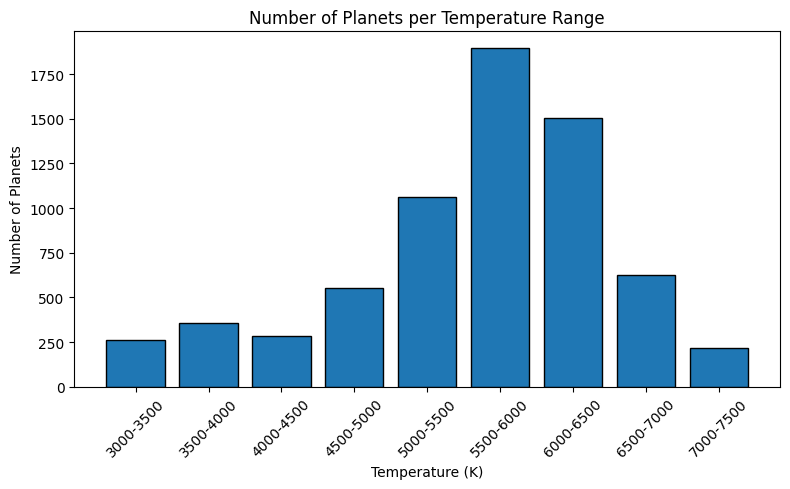

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv('TOI_Mar2025.csv')

temp_col = 'st_teff'

# Convert to numeric, drop NaNs
df[temp_col] = pd.to_numeric(df[temp_col], errors='coerce')
df = df.dropna(subset=[temp_col])

print(df[temp_col])
# Define your fixed Teff ranges
teff_ranges = [
    (3000, 3500), (3500, 4000), (4000, 4500),
    (4500, 5000), (5000, 5500), (5500, 6000),
    (6000, 6500), (6500, 7000), (7000, 7500),
]

# Count planets in each range
counts = []
labels = []
for low, high in teff_ranges:
    mask = (df[temp_col] >= low) & (df[temp_col] < high)
    counts.append(mask.sum())
    labels.append(f"{low}-{high}")

# Plot
plt.figure(figsize=(8, 5))
plt.bar(labels, counts, edgecolor='black')
plt.xlabel('Temperature (K)')
plt.ylabel('Number of Planets')
plt.title('Number of Planets per Temperature Range')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
